# Forestnet Dataset

## Intro

Forestnet [Irvin et al. 2020](https://arxiv.org/pdf/2011.05479) is a curated dataset of Landsat 8 satellite images of known forest loss events paired with driver annotations from expert interpreters in South Asia. 

## Dataset Characteristics

- **Modalities**: 
  - Landsat 8 (6 spectral bands) with superimposed forest loss events polygons
- **Spatial Resolution**: 
  - Landsat 8: 15
- **Temporal Resolution**: Multiple acquisitions per patch but treated as different samples
- **Image Dimensions**: 332x332 pixels (1.2km x 1.2km patches)
- **Labels**: Expert interpreters
- **Geographic Distribution**: South Asia
- **Temporal Coverage**: 2013-2017

## Dataset Setup and Initialization

In [1]:
from pathlib import Path

from geobench_v2.datamodules import GeoBenchForestnetDataModule
# Setup paths
PROJECT_ROOT = Path("../../")


# Initialize datamodule
datamodule = GeoBenchForestnetDataModule(
    img_size=332,  # Original resolution
    batch_size=16,
    num_workers=4,
    root=PROJECT_ROOT / "data" / "forestnet",
    download=True,
)


datamodule.setup("fit")
datamodule.setup("test")

print("Forestnet datamodule initialized successfully!")
print(f"Training samples: {len(datamodule.train_dataset)}")
print(f"Validation samples: {len(datamodule.val_dataset)}")
print(f"Test samples: {len(datamodule.test_dataset)}")

/opt/app-root/src/fm-geospatial/pf/envs/geo-env/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/app-root/src/fm-geospatial/pf/envs/geo-env/lib64/python3.11/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Initializing normalizer from class: MultiModalNormalizer
Initializing normalizer from class: MultiModalNormalizer
Initializing normalizer from class: MultiModalNormalizer
Forestnet datamodule initialized successfully!
Training samples: 6464
Validation samples: 989
Test samples: 993


## Geographic Distribution Visualization


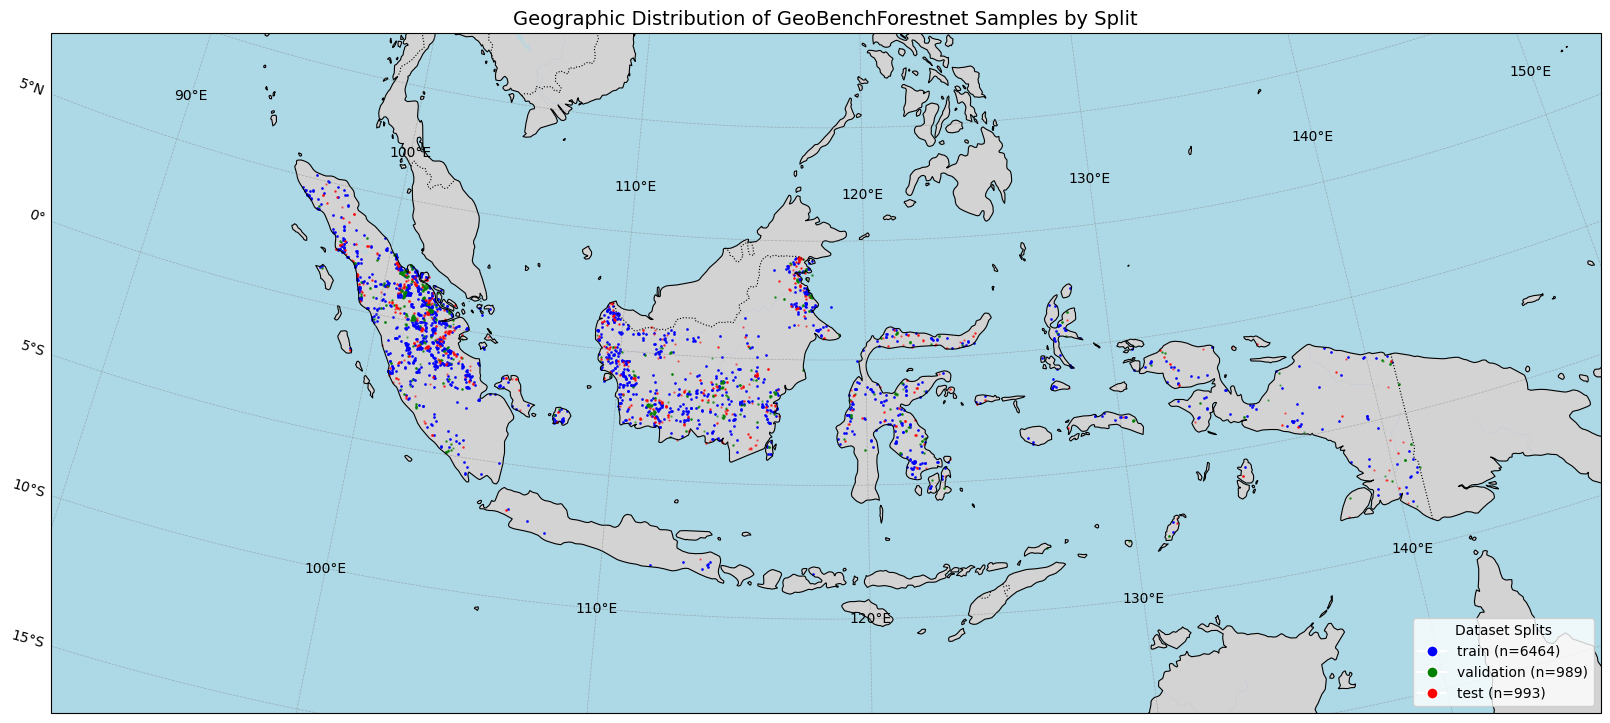

In [2]:
geo_fig = datamodule.visualize_geospatial_distribution()

## Sample Data Visualization

The sample includes Landsat 8, with some overimposed polygons of known forest loss events.

['B02', 'B03', 'B04', 'B8A', 'B11', 'B12']
[2, 1, 0]


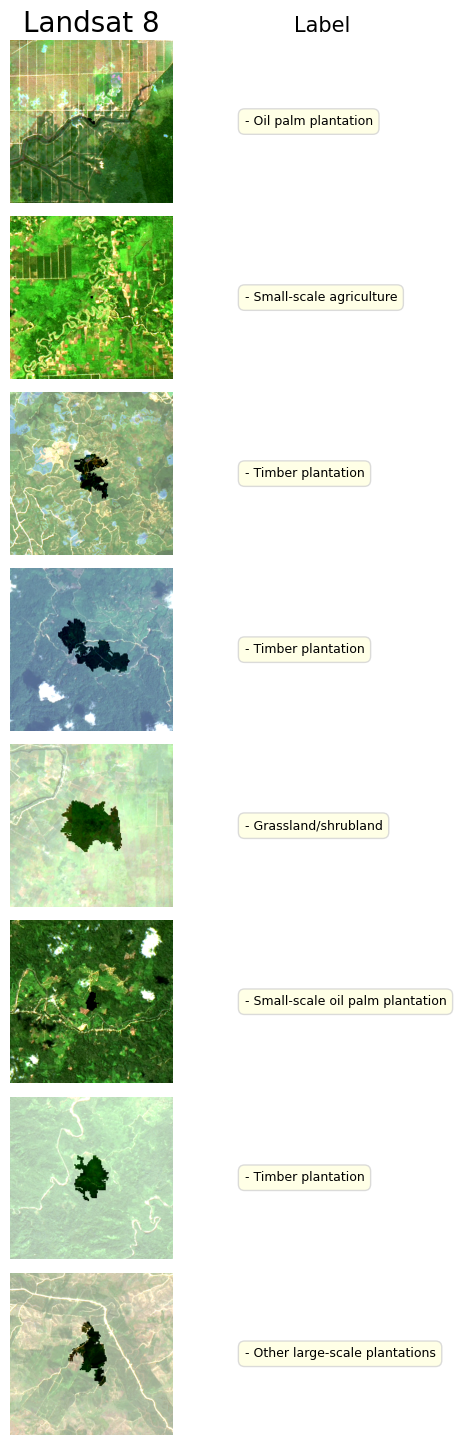

In [11]:
fig, batch = datamodule.visualize_batch()

## GeoBenchV2 Processing Pipeline

### Preprocessing Steps

1. **Split Generation**:
   - Used existing train/validation/test splits from GEO-Bench v1


## References

1. Irvin J, Sheng H, Ramachandran N, Johnson-Yu S, Zhou S, Story K, Rustowicz R, Elsworth C, Austin K, Ng AY. Forestnet: Classifying drivers of deforestation in indonesia using deep learning on satellite imagery. arXiv preprint arXiv:2011.05479. 2020 Nov 11

2. Lacoste A, Lehmann N, Rodriguez P, Sherwin E, Kerner H, Lütjens B, Irvin J, Dao D, Alemohammad H, Drouin A, Gunturkun M. Geo-bench: Toward foundation models for earth monitoring. Advances in Neural Information Processing Systems. 2023 Dec 15;36:51080-93.
